# 04 — Investment Thesis: Tesla vs BYD vs Ford

This notebook applies the **SCIR** framework to the data collected in notebook 01
and analysed in notebooks 02–03. Each thesis is tied to specific figures from that
dataset. The goal is not a buy or sell recommendation but a structured view on the
relative financial health of three EV archetypes.

- **Situation** — what the data shows, factually.
- **Complication** — what is driving it, and why it matters.
- **Implication** — what it means for an investor, including the *variant
  perception*: where the market's read and the data's read diverge.
- **Risk** — what would falsify the thesis.

Every figure below, valuation multiples included, comes from
`data/fundamentals.pkl`, built by notebook 01.

> **A note on what changed.** An earlier version of this analysis compared BYD's
> renminbi statements directly against Tesla's and Ford's dollar statements. That
> made BYD's free cash flow appear to be $36.1B rather than $5.0B and its P/E 2.4x
> rather than 17.5x, and the BYD and Ford theses were argued from those figures.
> Both have been rewritten against the corrected data. The conclusions moved.

In [1]:
import sys

sys.path.append("..")

import pandas as pd
import plotly.graph_objects as go

import config

fundamentals = pd.read_pickle("../data/fundamentals.pkl")
first, last = config.FIRST_YEAR, config.LAST_YEAR


def company(name):
    return fundamentals.query("company == @name").set_index("year")


def move(name, field, scale=1.0, unit=""):
    """First-to-last-year move for one metric, formatted for quoting in prose."""
    series = company(name)[field] / scale
    return f"{series.loc[first]:.1f}{unit} -> {series.loc[last]:.1f}{unit}"


print(fundamentals.set_index(["company", "year"])
      [["npm", "roa", "ccr"]].round(2)
      .join((fundamentals.set_index(["company", "year"])[["revenue", "free_cash_flow"]] / 1e9)
            .round(2).add_suffix("_$B"))
      .to_string())

                npm    roa   ccr  revenue_$B  free_cash_flow_$B
company year                                                   
Tesla   2022  15.41  15.25  1.17       81.46               7.57
        2023  15.50  14.07  0.88       96.77               4.36
        2024   7.26   5.81  2.10       97.69               3.58
BYD     2022   3.92   3.48  8.47       63.02               6.45
        2023   4.99   4.44  5.65       85.17               6.74
        2024   5.18   5.22  3.32      108.14               5.02
Ford    2022  -1.25  -0.77 -3.46      158.06              -0.01
        2023   2.47   1.59  3.43      176.19               6.68
        2024   3.18   2.06  2.62      184.99               6.74


## Tesla (TSLA) — Paying 189x for a Story the Statements Do Not Yet Tell

### Situation
Tesla remains the most profitable of the three on margin — 7.3% net profit margin
against BYD's 5.2% and Ford's 3.2% — but the lead has narrowed sharply. Net profit
margin fell **8.2 percentage points** over the window (15.4% → 7.3%) and return on
assets fell **9.4 points** (15.2% → 5.8%), both close to halving. Revenue grew
**0.9%** in 2024. Free cash flow is **$3.6B**, the lowest of the three, having
fallen from $7.6B in 2022. Cash conversion is 2.10 — healthy in absolute terms,
but the *lowest* of the three, and it reached that level largely because net income
fell 53% while operating cash flow rose 13%.

### Complication
The margin compression is deliberate: a price war fought from 2023 to defend
volume against BYD. That was a choice, and it worked in the narrow sense — but
2024 revenue growth of 0.9% says the volume it bought has stopped arriving. Return
on assets fell further than margin because the asset base grew **48%** across the
window while net income fell 44%: Tesla built capacity into a demand curve that
flattened. There is still no visible margin floor.

### Implication
At 7.3% net profit margin Tesla is converging on the legacy-automaker economics it
was built to escape, while priced at **189x earnings against Ford's 6x**. Its
EV/EBITDA of 91x and FCF yield of 0.3% say the same thing from two other
directions. The entire gap between Tesla's price and Tesla's financial statements
is a claim about FSD, Optimus and energy storage.

**Variant perception:** the widely-held view is that Tesla's cash generation is
robust and its 2024 cash-conversion recovery to 2.10 confirms it. The data does not
support that reading — the ratio improved chiefly because its denominator
collapsed, and Tesla still generates *less* free cash than either competitor,
including Ford, a company worth a thirty-eighth as much. On the evidence in
these statements, Tesla's near-term cash position is **weaker** than consensus
assumes, not stronger. This is a reversal of the position taken in the earlier
version of this notebook, which read the same 2.10 as a sign of hidden strength.

### Risk
The bull case rests entirely on non-automotive catalysts that do not appear in
these financials — which is not evidence they will fail, only that this dataset
cannot price them. Key-person concentration cuts both ways: it sustains a valuation
premium no other automaker could hold, and it is an asymmetric single point of
failure. **Falsified if** 2025 revenue growth returns to double digits with margins
stabilising above 10%, which would show the price war bought durable share rather
than a pause.

In [2]:
tesla = company("Tesla")
print("=== TESLA ===")
print(f"NPM   {move('Tesla', 'npm', unit='%')}   ({tesla['npm'].loc[last] - tesla['npm'].loc[first]:+.1f} pp)")
print(f"ROA   {move('Tesla', 'roa', unit='%')}   ({tesla['roa'].loc[last] - tesla['roa'].loc[first]:+.1f} pp)")
print(f"FCF   ${move('Tesla', 'free_cash_flow', 1e9, 'B')}")
print(f"Revenue growth {last}: {(tesla['revenue'].loc[last] / tesla['revenue'].loc[last-1] - 1) * 100:.1f}%")
print(f"Asset base     {move('Tesla', 'total_assets', 1e9, 'B')}  "
      f"({(tesla['total_assets'].loc[last] / tesla['total_assets'].loc[first] - 1) * 100:+.0f}%)")
print(f"Net income     {move('Tesla', 'net_income', 1e9, 'B')}  "
      f"({(tesla['net_income'].loc[last] / tesla['net_income'].loc[first] - 1) * 100:+.0f}%)")
print(f"CCR by year:\n{tesla['ccr'].round(2).to_string()}")

=== TESLA ===
NPM   15.4% -> 7.3%   (-8.2 pp)
ROA   15.2% -> 5.8%   (-9.4 pp)
FCF   $7.6B -> 3.6B
Revenue growth 2024: 0.9%
Asset base     82.3B -> 122.1B  (+48%)
Net income     12.6B -> 7.1B  (-44%)
CCR by year:
year
2022    1.17
2023    0.88
2024    2.10


## BYD (BYDDY) — The Growth Is Real; the Cash Story Was Not

### Situation
BYD is the only company here compounding. Revenue grew from **$63.0B to $108.1B**
(+72%), including +27% in 2024 — roughly four times the pace of either competitor
across the window. Net profit margin rose 3.9% → 5.2% and return on assets
3.5% → 5.2%, the latter now within striking distance of Tesla's 5.8%. Cash
conversion is the strongest of the three at 3.32. Free cash flow is **$5.0B**:
more than Tesla's $3.6B, less than Ford's $6.7B.

### Complication
That $5.0B figure is the correction that reshapes this thesis. Read in renminbi
and compared against dollar peers, BYD's free cash flow appeared to be $36.1B and
its cash generation looked like the dominant fact about the company. It is not.
BYD is a *fast-growing, improving-margin* business with ordinary cash generation
for its size — not a cash machine. The earlier version of this thesis argued the
capex build was suppressing an enormous cash engine; on the corrected data the
engine was never that large.

The capex pattern still matters, but it is milder than it appeared: capex of
$14.5B → $13.5B against operating cash flow that fell from $24.0B to $18.6B in
2024. Cash conversion falling 8.47 → 3.32 is not deterioration either — net income
grew 127% while operating cash flow fell 11%, so the ratio is converging towards a
normal manufacturing range from an extreme base.

### Implication
BYD is the most defensible position in this set on the numbers: **18x earnings for
27% revenue growth, rising margins and the best cash conversion of the three.**
Tesla is priced at eleven times BYD's multiple while growing revenue at barely a
third of BYD's rate across the window — and a thirtieth of it in 2024. The
discount is not a financial judgement — it is a geopolitical and structural one:
EU tariffs of up to 35%, US market exclusion, ADR ownership rather than direct
equity, and a disclosure regime that cannot be cross-checked against an SEC filing
the way Tesla's and Ford's can.

**Variant perception:** the market treats BYD's China risk as a reason not to
underwrite the growth at all. The data suggests the risk is being priced as though
it were a *financial* fragility, when the financials are the strongest-improving in
the set. The honest counter is that this remains a discount for a real,
unquantifiable risk — an investor who cannot bear a policy shock should not own it
at any multiple, and that is a legitimate position rather than a mispricing.

### Risk
Single-sourced data is itself a risk here: BYD files nothing with the SEC, so
unlike Tesla and Ford none of these figures can be reconciled to a regulated
filing. Beyond that, state backing is both the moat and the liability — the same
authority that underwrites scale can mandate decisions that destroy margin.
**Falsified if** cash conversion falls below 1.5, or if revenue growth drops below
10% while capex stays elevated — the combination that would mean the capacity build
is outrunning demand.

In [3]:
byd = company("BYD")
print("=== BYD ===")
print(f"Revenue  ${move('BYD', 'revenue', 1e9, 'B')}  "
      f"({(byd['revenue'].loc[last] / byd['revenue'].loc[first] - 1) * 100:+.0f}%)")
print(f"NPM      {move('BYD', 'npm', unit='%')}   ({byd['npm'].loc[last] - byd['npm'].loc[first]:+.1f} pp)")
print(f"ROA      {move('BYD', 'roa', unit='%')}   ({byd['roa'].loc[last] - byd['roa'].loc[first]:+.1f} pp)")
print(f"FCF      ${move('BYD', 'free_cash_flow', 1e9, 'B')}")
print(f"OCF      ${move('BYD', 'operating_cash_flow', 1e9, 'B')}  "
      f"({(byd['operating_cash_flow'].loc[last] / byd['operating_cash_flow'].loc[first] - 1) * 100:+.0f}%)")
print(f"Capex    ${move('BYD', 'capex', 1e9, 'B')}")
print(f"Net income ${move('BYD', 'net_income', 1e9, 'B')}  "
      f"({(byd['net_income'].loc[last] / byd['net_income'].loc[first] - 1) * 100:+.0f}%)")
print(f"CCR by year:\n{byd['ccr'].round(2).to_string()}")

=== BYD ===
Revenue  $63.0B -> 108.1B  (+72%)
NPM      3.9% -> 5.2%   (+1.3 pp)
ROA      3.5% -> 5.2%   (+1.7 pp)
FCF      $6.4B -> 5.0B
OCF      $20.9B -> 18.6B  (-11%)
Capex    $14.5B -> 13.5B
Net income $2.5B -> 5.6B  (+127%)
CCR by year:
year
2022    8.47
2023    5.65
2024    3.32


## Ford (F) — Cheap Equity, Expensive Enterprise

### Situation
Ford has the weakest profitability of the three — 3.2% net profit margin, 2.1%
return on assets — but the clearest recovery: margin rose 4.4 points from a 2022
loss (−1.3% → 3.2%) and return on assets 2.8 points (−0.8% → 2.1%). It also
generates **the most free cash flow of the three at $6.7B**, against BYD's $5.0B
and Tesla's $3.6B, and carries the highest FCF yield at **19.1%** on a P/E of
**6.0x**. Cash conversion of 2.62 sits between the other two.

### Complication
Two things sit underneath those aggregates, pulling in opposite directions.

The first is segment mix: a profitable ICE business (Ford Blue, Ford Pro)
subsidising a loss-making EV division (Model e). **Ford is funding an EV transition
using profits from the business the transition is killing** — and Ford Pro,
commercial vehicles and services, is among the most profitable segments in the
industry.

The second is the balance sheet, and it is the reason Ford's two valuation lenses
disagree. Ford carries **$160.9B of debt against a $35.2B market capitalisation** —
a ratio of 4.6x, almost all of it Ford Credit's lending book. On equity multiples
Ford is the cheapest company here by a distance. On enterprise value it is
**12.2x EBITDA, more than twice BYD's 5.5x**. The 19.1% FCF yield and the 12.2x
EV/EBITDA describe the same company; the first ignores the debt and the second
does not.

### Implication
Ford is cheap for a reason that is visible rather than hidden, which is unusual and
worth something. The equity is a leveraged claim on an industrial recovery, and
leverage is why the P/E is 6x. An investor buying the 19% FCF yield without pricing
$160.9B of debt is buying half a number.

**Variant perception:** this is the one that has changed most against the corrected
data. The earlier version of this thesis concluded Ford had *no* variant perception
— that the market saw it accurately. That was an artefact of comparing Ford's cash
generation against BYD's inflated figure. Corrected, Ford is the **largest absolute
cash generator in the set**, and its aggregate numbers understate a genuinely
profitable commercial franchise. The variant perception is that Ford Pro's economics
are worth more than a 6x blended multiple implies — available only to an investor
who can hold the finance-arm leverage alongside it.

### Risk
Structural rather than cyclical: Ford is what Tesla and BYD were built to disrupt,
and its moats — the F-150 franchise, the dealer network — were built for a market
that is changing shape. The finance arm that makes the enterprise expensive is also
credit-cycle exposed, and a consumer credit deterioration would hit earnings and the
balance sheet together. **Falsified if** Model e reaches segment profitability by
2026, which would mean the transition is being funded successfully rather than
merely being funded.

In [4]:
ford = company("Ford")
print("=== FORD ===")
print(f"NPM   {move('Ford', 'npm', unit='%')}   ({ford['npm'].loc[last] - ford['npm'].loc[first]:+.1f} pp)")
print(f"ROA   {move('Ford', 'roa', unit='%')}   ({ford['roa'].loc[last] - ford['roa'].loc[first]:+.1f} pp)")
print(f"FCF   ${move('Ford', 'free_cash_flow', 1e9, 'B')}")
print(f"CCR {last}: {ford['ccr'].loc[last]:.2f}   ({first} is not meaningful — divides by a net loss)")
print(f"Total debt ${move('Ford', 'total_debt', 1e9, 'B')}")

print("\n2024 free cash flow, all three (USD):")
print((fundamentals.query("year == @last").set_index("company")["free_cash_flow"] / 1e9)
      .round(2).sort_values(ascending=False).to_string())

=== FORD ===
NPM   -1.3% -> 3.2%   (+4.4 pp)
ROA   -0.8% -> 2.1%   (+2.8 pp)
FCF   $-0.0B -> 6.7B
CCR 2024: 2.62   (2022 is not meaningful — divides by a net loss)
Total debt $140.5B -> 160.9B

2024 free cash flow, all three (USD):
company
Ford     6.74
BYD      5.02
Tesla    3.58


## Comparative Ranking

The earlier version of this notebook ranked **Tesla first** on the strength of its
cash-conversion recovery, while notebook 05 and the README both concluded BYD was
the better position — the project contradicted itself. Both halves of that
contradiction were argued partly from the uncorrected BYD figures. Re-run on the
corrected data, the ranking below is the one consistent view, and notebook 05's
scorecard agrees with it.

Ranked on **financial health and what is being paid for it**, over 2022–2024:

### 1. BYD — the growth is priced as if it were not happening
The only company compounding: +72% revenue, margins and returns rising every year,
the strongest cash conversion of the three, at 18x earnings. Ranked first because
it is the only position where the operating trend and the valuation point the same
way. It is *not* ranked first for cash generation — that was the error in the
previous version, and Ford beats it on that measure. The China risk is real,
unquantifiable and correctly discounted; it is a reason to size the position
carefully, not a reason the financial case is wrong.

### 2. Ford — cheapest on the numbers, for legible reasons
Largest absolute free cash flow ($6.7B), highest FCF yield (19.1%), lowest P/E
(6.0x), and a genuine margin recovery from a loss. Ranked second rather than first
because the growth is not there — 17% over two years — and because the 4.6x
debt-to-market-cap ratio means the equity is a leveraged claim, so the cheapness
carries a balance-sheet reason rather than being free.

### 3. Tesla — the best business, at a price the statements cannot support
Still the highest margin in the set and the strongest brand and software position.
Ranked last because none of that is in dispute and all of it is in the price: 189x
earnings, 91x EV/EBITDA, a 0.3% FCF yield, 0.9% revenue growth in 2024, and the lowest
free cash flow of the three. The ranking is a statement about price relative to
demonstrated financials, not about business quality — on business quality alone
Tesla ranks first.

**Caveat:** this ranking uses three years of annual financial data and the
valuation multiples in notebook 05. It excludes forward guidance, segment-level
detail, product roadmaps and market context. **It is an analytical exercise, not
investment advice.**

In [5]:
summary = (fundamentals.query("year == @last")
           .set_index("company")[["npm", "roa", "free_cash_flow", "ccr", "revenue"]]
           .copy())
summary["free_cash_flow"] /= 1e9

growth = {name: (company(name)["revenue"].loc[last] / company(name)["revenue"].loc[first] - 1) * 100
          for name in config.COMPANIES}
summary["revenue_growth"] = pd.Series(growth)
summary = summary.drop(columns="revenue")

# Multiples come from notebook 01 alongside the fundamentals, so they are always present.
summary = summary.join(fundamentals.query("year == @last").set_index("company")[["pe", "ev_ebitda"]])

summary["ranking"] = pd.Series({"BYD": 1, "Ford": 2, "Tesla": 3})
summary.columns = ["NPM (%)", "ROA (%)", "FCF ($B)", "CCR",
                   f"Rev growth {first}-{last} (%)", "P/E", "EV/EBITDA", "Rank"]

print(f"=== {last} SUMMARY (USD) ===")
print(summary.sort_values("Rank").round(2).to_string())

=== 2024 SUMMARY (USD) ===
         NPM (%)  ROA (%)  FCF ($B)   CCR  Rev growth 2022-2024 (%)     P/E  EV/EBITDA  Rank
company                                                                                     
BYD         5.18     5.22      5.02  3.32                     71.60   17.53       5.51     1
Ford        3.18     2.06      6.74  2.62                     17.04    5.99      12.16     2
Tesla       7.26     5.81      3.58  2.10                     19.92  189.31      91.10     3


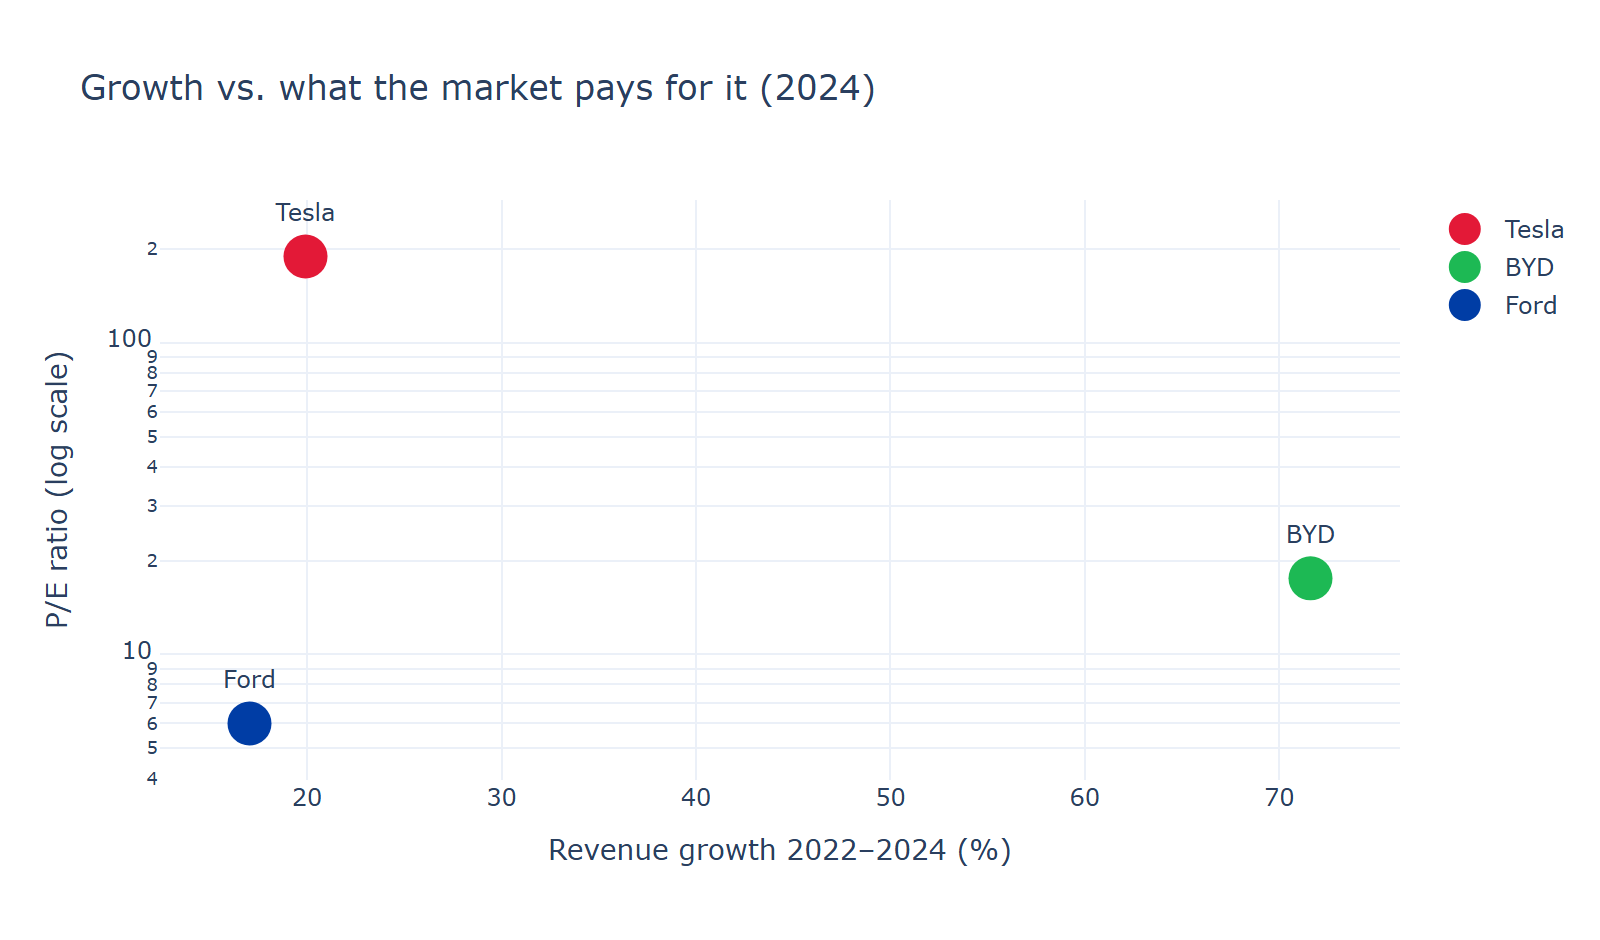

In [6]:
# The one chart: growth against what is paid for it.
plot = summary.reset_index()
fig = go.Figure()
for _, row in plot.iterrows():
    fig.add_trace(go.Scatter(
        x=[row[f"Rev growth {first}-{last} (%)"]], y=[row["P/E"]],
        mode="markers+text", text=[row["company"]], textposition="top center",
        marker=dict(size=22, color=config.COLORS[row["company"]]),
        name=row["company"],
    ))
fig.update_layout(
    title_text=f"Growth vs. what the market pays for it ({last})",
    xaxis_title=f"Revenue growth {first}–{last} (%)",
    yaxis_title="P/E ratio (log scale)",
    yaxis_type="log", template="plotly_white", height=470, width=800,
)
fig.show()

The chart is the thesis in one frame. The vertical axis is logarithmic, which is
the only way to fit 6x and 189x on the same plot — and needing a log axis at all is
itself the finding.

Tesla sits top-left: the highest price for the slowest growth. BYD sits
bottom-right: the fastest growth at close to the lowest price. Ford sits
bottom-left, cheap and static. On these three years of data, the market is paying
most for the company growing least.